$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$

# 图 2.9

我们构建的统计模型为：

$$
y = h(\boldsymbol{x}) + \epsilon
$$

其中 $h(\boldsymbol{x}) \sim GP(\mu, \tau^2R(\cdot))$，噪声项 $\epsilon$ 独立同分布，服从正态分布 $\epsilon \stackrel{iid}{\sim} \mathcal{N}(0, \sigma^2)$。现有数据集 $\{(\boldsymbol{x}_i, y_i)\}_{i=1}^n$。暂且假定参数 $\mu$、$\tau^2$、$\sigma^2$ 以及相关参数 $\boldsymbol{\theta}$ 均为已知量，后续将采用经验贝叶斯方法对这些参数进行估计。

设 $\boldsymbol{y} = (y_1, \dots, y_n)'$ 的边缘分布为

$$
\boldsymbol{y} \sim \mathcal{N}(\mu\boldsymbol{1}, \tau^2\boldsymbol{R} + \sigma^2\boldsymbol{I})
$$

而 $h(\boldsymbol{x})$ 与 $\boldsymbol{y}$ 的联合分布满足

$$
\begin{bmatrix}
h(\boldsymbol{x}) \\ \boldsymbol{y}
\end{bmatrix}
\sim \mathcal{N}_{1+n}
\left(\begin{bmatrix}
\mu \\ \mu\boldsymbol{1}
\end{bmatrix},
\begin{bmatrix}
\tau^2 & \tau^2\boldsymbol{r}(\boldsymbol{x})' \\
\tau^2\boldsymbol{r}(\boldsymbol{x}) & \tau^2\boldsymbol{R} + \sigma^2\boldsymbol{I}
\end{bmatrix}\right)
$$

式中 $\boldsymbol{r}(\boldsymbol{x}) = \{R(\boldsymbol{x} -\boldsymbol{x}_i)\}_{i=1}^n$，$\boldsymbol{R} = \{R(\boldsymbol{x}_i -\boldsymbol{x}_j)\}_{i,j=1}^n$。

利用引理 2.2，对于固定的 $\boldsymbol{x}$，可求得 $h(\boldsymbol{x})$ 的后验分布：

$$
h(\boldsymbol{x})|\boldsymbol{y} \sim \mathcal{N}\left( \mu + \boldsymbol{r}(\boldsymbol{x})'(\boldsymbol{R}+\lambda\boldsymbol{I})^{-1}(\boldsymbol{y}-\mu\boldsymbol{1}),\ \tau^2\left\{1-\boldsymbol{r}(\boldsymbol{x})'(\boldsymbol{R}+\lambda\boldsymbol{I})^{-1}\boldsymbol{r}(\boldsymbol{x})\right\} \right) \tag{2.43}
$$

其中 $\lambda = \sigma^2/\tau^2$。位置 $\boldsymbol{x}$ 处新增观测值的预测方差为：

$$
\begin{align*}
s^2(\boldsymbol{x}) &= var\{h(\boldsymbol{x})+\epsilon|\boldsymbol{y}\} \\
&= var\{h(\boldsymbol{x})|\boldsymbol{y}\} + var(\epsilon) \quad (\text{由相互独立性可得}) \\
&= \tau^2\left\{1+\lambda - \boldsymbol{r}(\boldsymbol{x})'(\boldsymbol{R}+\lambda\boldsymbol{I})^{-1}\boldsymbol{r}(\boldsymbol{x})\right\}.
\end{align*}
$$

据此可得 95% 预测区间为 $\hat{y}(\boldsymbol{x}) \pm 2s(\boldsymbol{x})$。

高斯过程表达式还提供了一种不同于交叉验证法的方式来估计未知参数。参数的似然函数满足：

$$
L \propto \frac{1}{\tau^n |\boldsymbol{R}+\lambda\boldsymbol{I}|^{1/2}} \exp\left\{ -\frac{1}{2\tau^2}(\boldsymbol{y}-\mu\boldsymbol{1})'(\boldsymbol{R}+\lambda\boldsymbol{I})^{-1}(\boldsymbol{y}-\mu\boldsymbol{1}) \right\}
$$

将该似然函数关于 $\mu$、$\tau^2$、$\lambda$ 和 $\boldsymbol{\theta}$ 最大化，可得：

$$
\hat{\mu}=\frac{\boldsymbol{1}'(\boldsymbol{R}+\lambda\boldsymbol{I})^{-1}\boldsymbol{y}}{\boldsymbol{1}'(\boldsymbol{R}+\lambda\boldsymbol{I})^{-1}\boldsymbol{1}} \tag{2.44}
$$

$$
\hat{\tau}^2=\frac{1}{n}(\boldsymbol{y}-\hat{\mu}\boldsymbol{1})'(\boldsymbol{R}+\lambda\boldsymbol{I})^{-1}(\boldsymbol{y}-\hat{\mu}\boldsymbol{1}) \tag{2.45}
$$

$$
(\hat{\lambda},\hat{\boldsymbol{\theta}})=\argmin_{\lambda,\boldsymbol{\theta}} \left\{ n\log\hat{\tau}^2 + \log|\boldsymbol{R}+\lambda\boldsymbol{I}| \right\} \tag{2.46}
$$

再次考察由式 (2.1) 中的一维测试函数生成的 20 个数据点。借助 R 语言程序包 rkriging（黄与约瑟夫，2024），采用高斯相关函数 $R(u-v) = \exp\left\{-(u-v)^2/\theta^2\right\}$ 拟合高斯过程回归模型。针对两种采样方案——等间距采样点与适配九次多项式的 D 最优采样点，其预测结果及 95% 置信区间如图 2.9 所示。不出所料，该模型的预测效果与核岭回归相近，但高斯过程回归的优势在于可为预测值给出不确定性区间。对比图 2.6、图 2.7 右侧子图里的八次多项式模型，高斯过程回归无论是预测结果还是不确定性区间的表现都更为优异。高斯过程回归的不确定性区间具备合理特性：在已有观测数据的区间内区间宽度更窄，在数据稀疏区域区间则更宽。

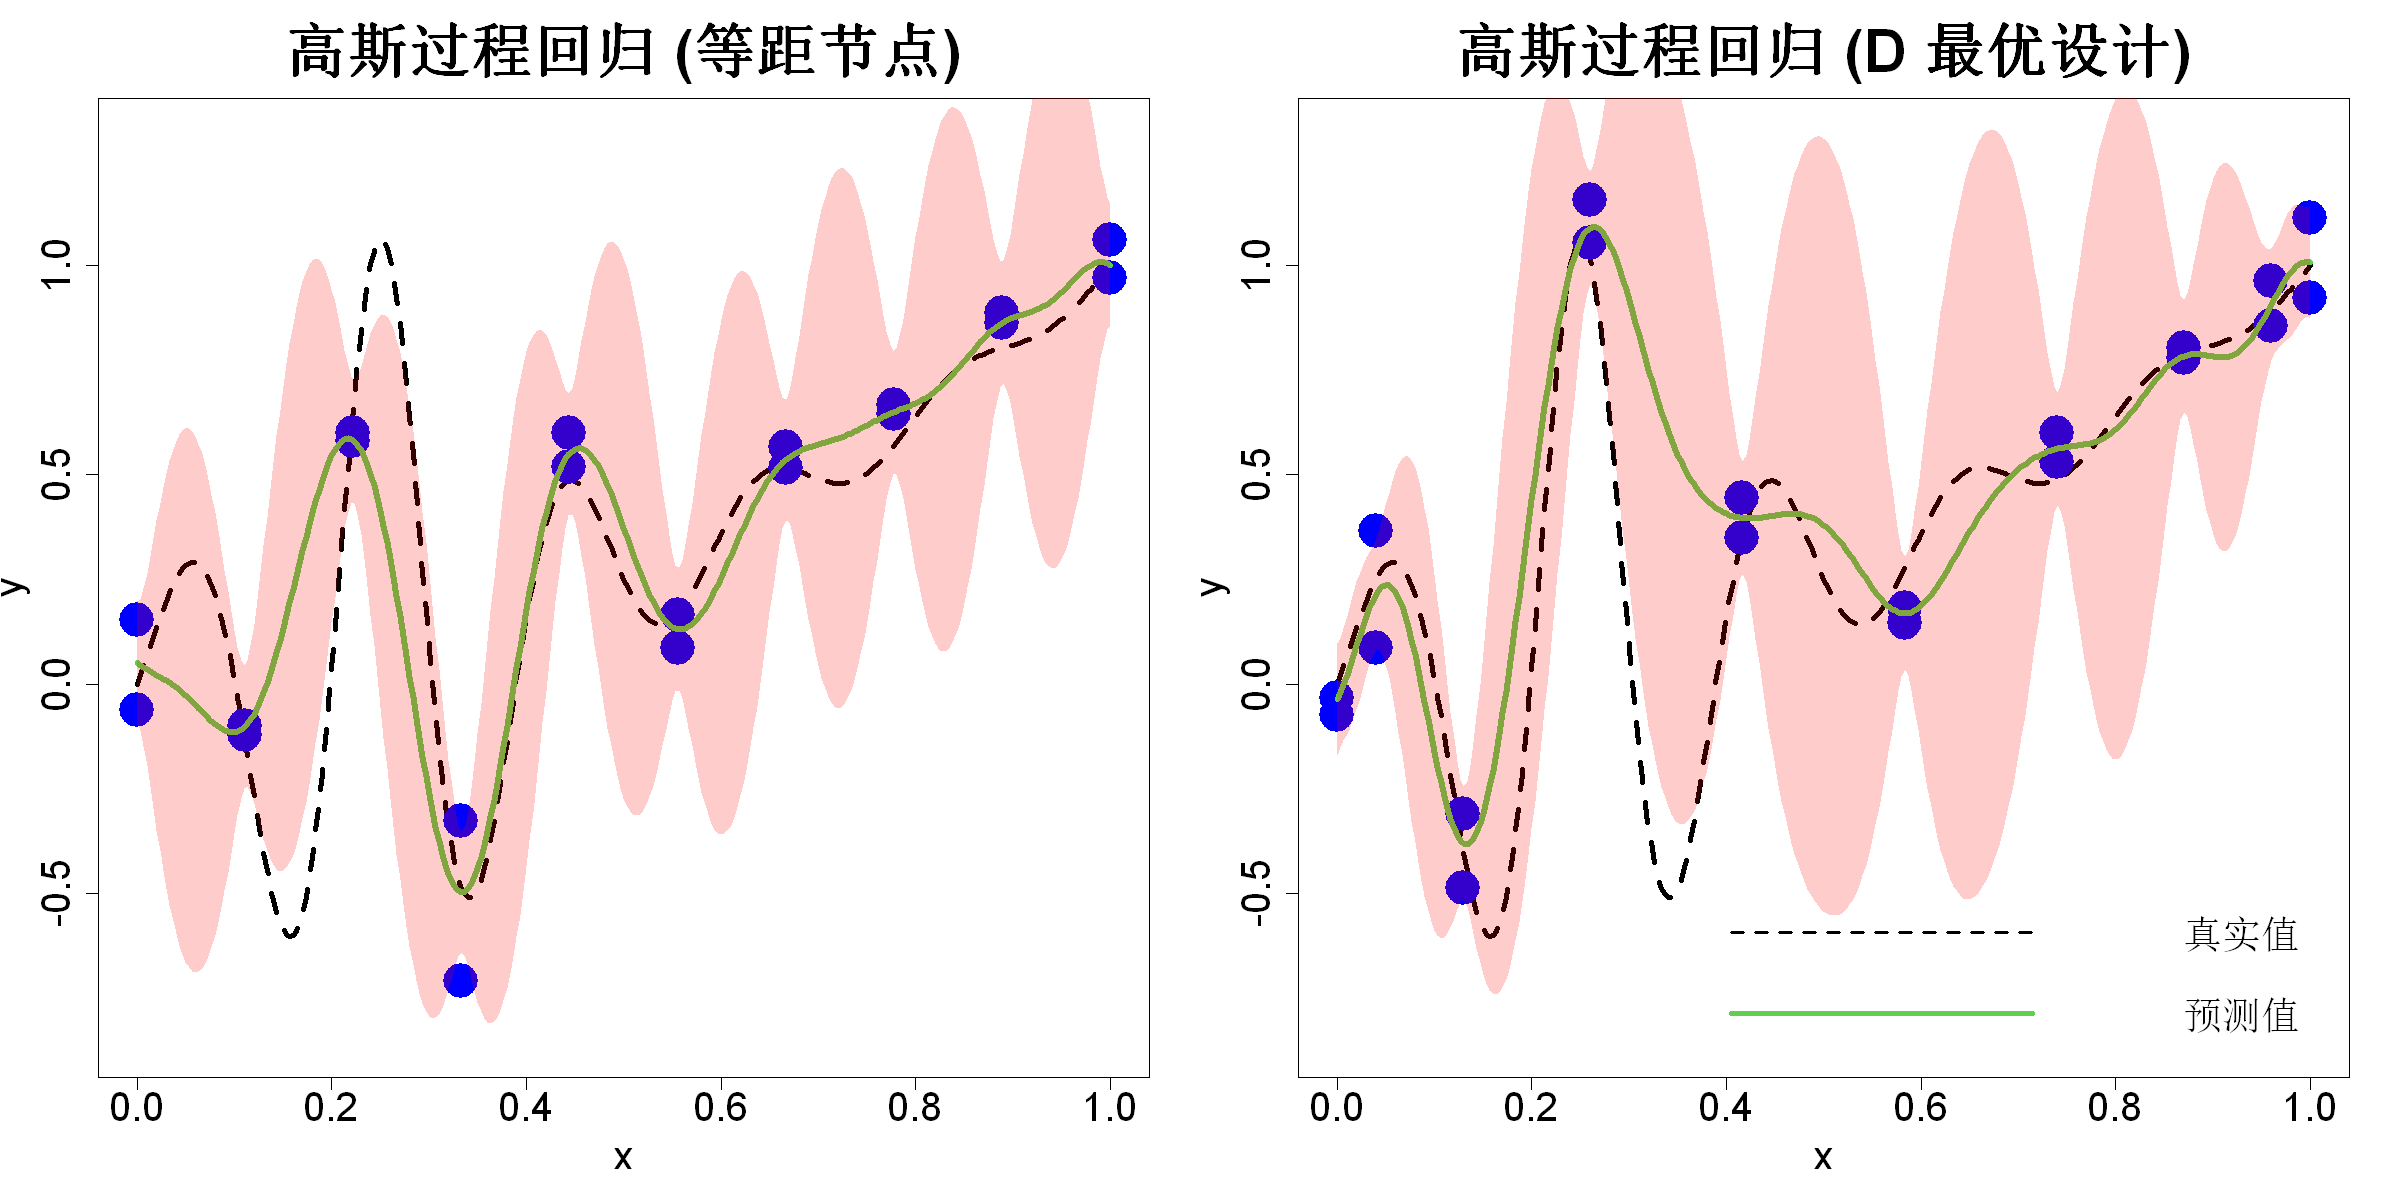

In [5]:
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/2.9-D.csv") || !file.exists("data/2.9-pred.csv")) {
  f=function(x)sin(10*pi*x)/(1+64*(x-.25)^2)+x^2
  test=seq(0,1,length=301)
  true=f(test)
  n=10;r=2
  D1=rep(((1:n)-1)/(n-1),r)
  set.seed(1)
  e=rnorm(n*r,sd=.1)
  y1=f(D1)+e
  library(rkriging)
  pred1=Fit.Kriging(D1,y1,interpolation=FALSE,kernel.parameters=list(type="Gaussian"))|>
    Predict.Kriging(test)
  mean1=pred1$mean
  low1=mean1-2*pred1$sd
  up1=mean1+2*pred1$sd
  tests=2*test-1
  cand_df=data.frame(x=tests)
  library(AlgDesign)
  a=optFederov(~1+x+I(x^2)+I(x^3)+I(x^4)+I(x^5)+I(x^6)+I(x^7)+I(x^8)+I(x^9),nTrials=n,data=cand_df,approximate=FALSE)
  D2=(rep(c(a$design[,1]),r)+1)/2
  e=rnorm(n*r,sd=.1)
  y2=f(D2)+e
  pred2=Fit.Kriging(D2,y2,interpolation=FALSE,kernel.parameters=list(type="Gaussian"))|>
    Predict.Kriging(test)
  mean2=pred2$mean
  low2=mean2-2*pred2$sd
  up2=mean2+2*pred2$sd
  write.csv(data.frame(D1=D1,y1=y1,D2=D2,y2=y2),file="data/2.9-D.csv",row.names=FALSE)
  write.csv(data.frame(test=test,true=true,pred1=mean1,low1=low1,up1=up1,pred2=mean2,low2=low2,up2=up2),file="data/2.9-pred.csv",row.names=FALSE)
}

df_D=read.csv("data/2.9-D.csv")
D1=df_D$D1;y1=df_D$y1;D2=df_D$D2;y2=df_D$y2
pred=read.csv("data/2.9-pred.csv")
test=pred$test;true=pred$true;mean1=pred$pred1;low1=pred$low1;up1=pred$up1;mean2=pred$pred2;low2=pred$low2;up2=pred$up2

options(repr.plot.width=20,repr.plot.height=10)
par(mfrow=c(1,2))
plot(test,true,type="l",lty=2,lwd=4,xlab="x",ylab="y",ylim=c(min(true)-.25,max(true)+.25),main="高斯过程回归 (等距节点)",cex.main=3,cex.lab=2,cex.axis=2)
points(D1,y1,pch=16,cex=4,col="blue")
lines(test,mean1,col=3,lwd=5)
polygon(c(test,rev(test)),c(low1,rev(up1)),col=adjustcolor("red",0.2),border=NA)
plot(test,true,type="l",lty=2,lwd=4,xlab="x",ylab="y",ylim=c(min(true)-.25,max(true)+.25),main="高斯过程回归 (D 最优设计)",cex.main=3,cex.lab=2,cex.axis=2)
points(D2,y2,pch=16,cex=4,col="blue")
lines(test,mean2,col=3,lwd=5)
polygon(c(test,rev(test)),c(low2,rev(up2)),col=adjustcolor("red",0.2),border=NA)
legend(.25,-.4,legend=c("真实值","预测值"),lty=c(2,1),col=c(1,3),lwd=c(3,4),bty="n",cex=2)

$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$